# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Автор работы Гомма Евгений Дата: 27.03.2026

Цель проекта — спрогнозировать отток клиентов для сервиса доставки кофе Happy Beans Coffee.

# План работы

Компания сталкивается с потерей 10 % клиентской базы каждый месяц, что снижает выручку и неэффективно расходует маркетинговый бюджет. Проект по прогнозированию оттока клиентов поможет:

- Принять меры по удержанию клиентов (например, предложить персональные скидки, промокоды и специальные акции тем, кто потенциально готов отказаться от услуг компании); 

- оптимизировать бюджет (снизить расходы на маркетинг и перенаправить ресурсы на целевые рекламные кампании для удержания клиентов); 

- повысить прогнозируемость (точнее планировать будущие доходы и понимать ценность клиентской базы). 

Для достижения цели необходимо построить модель бинарной классификации, которая будет прогнозировать вероятность оттока каждого клиента в следующем месяце. Модель должна определять статус клиентов как «Клиент лояльный» или «Клиент может уйти». 

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
# Базовые библиотеки
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Модели и метрики
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV

# Препроцессинг
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score

# Метрики
from sklearn.metrics import precision_recall_curve, auc

# Игнор предупреждений (чтобы ноут был чистый)
import warnings
warnings.filterwarnings('ignore')

# Фиксация random_state
RANDOM_STATE = 42

### Импорт библиотек и фиксация random_state

Импортированы основные библиотеки для анализа данных, визуализации и построения моделей.

Для обеспечения воспроизводимости результатов зафиксировано значение random_state = 42, которое будет использоваться во всех алгоритмах и процедурах разбиения данных.

In [2]:
# Путь к файлу (для платформы Я.Практикум)

try:
    df = pd.read_csv('coffee_churn_dataset.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv',sep=',',decimal='.')
# Быстрая проверка
df.head()


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


### Загрузка данных

Данные загружены из CSV-файла с использованием разделителя "," и корректного формата для чисел с плавающей точкой (decimal=".").

Каждая строка датасета соответствует одному пользователю, а признаки уже агрегированы за последние 4 недели.

In [3]:
print('Размер датасета:', df.shape)
print('\nТипы данных:')
print(df.dtypes.value_counts())

df.info()

Размер датасета: (10450, 27)

Типы данных:
float64    16
object     10
int64       1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seaso

### Первичный осмотр данных

Датасет содержит информацию о пользователях сервиса доставки кофе.

Проведена базовая проверка структуры данных:
- определено количество строк и столбцов,
- изучены типы данных,
- проверено наличие пропусков.

Данные представлены в виде аналитической витрины: одна строка соответствует одному клиенту.

### Вывод

Данные успешно загружены и доступны для дальнейшего анализа.

Формат данных соответствует ожидаемому: признаки представлены в виде числовых и категориальных переменных, каждая строка соответствует отдельному пользователю.

Ошибок при загрузке не обнаружено, структура датасета корректна, что позволяет перейти к этапу исследовательского анализа данных (EDA).

## Этап . Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

### . Первичный анализ данных

На данном этапе проводится первичный исследовательский анализ данных.

Цели этапа:
- изучить структуру датасета;
- описать пользователей и их поведение;
- проанализировать целевую переменную;
- выявить пропуски, выбросы и потенциально неинформативные признаки;
- определить признаки, требующие кодирования;
- оценить возможности генерации новых признаков;
- изучить корреляции между числовыми переменными.

Каждая строка датасета соответствует одному пользователю сервиса доставки кофе, а признаки уже агрегированы за последние 4 недели.

In [4]:
print('Размер датасета:', df.shape)
print('\nПервые 5 строк:')
display(df.head())

Размер датасета: (10450, 27)

Первые 5 строк:


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [5]:
print('\nТипы данных:')
display(df.dtypes)


Типы данных:


user_id                      object
days_since_last_order       float64
order_frequency_month       float64
order_frequency_week        float64
avg_order_value             float64
median_order_value          float64
total_spent_last_month      float64
total_spent_last_week       float64
discount_usage_rate         float64
last_coffee_type             object
preferred_roast              object
milk_preference              object
seasonal_menu_tried         float64
coffee_bean_origin           object
last_drink_size              object
subscription_status          object
app_opens_per_week          float64
notifications_enabled       float64
review_rating_last_10       float64
review_rating_last_1        float64
app_crashes_last_month      float64
seasons                      object
days_since_last_promo       float64
phone_type                   object
coffee_preference_change    float64
geo_location                 object
churn                         int64
dtype: object

Анализ типов данных показал, какие признаки являются числовыми, а какие категориальными. Это важно для дальнейшей обработки данных: числовые признаки можно использовать в расчётах и моделях напрямую, а категориальные признаки при необходимости потребуется кодировать. Также проверка типов помогает выявить признаки с некорректным форматом хранения данных.

In [6]:
print('\nКоличество пропусков:')
display(df.isna().sum().sort_values(ascending=False))


Количество пропусков:


seasonal_menu_tried         989
days_since_last_order       945
total_spent_last_week       944
subscription_status         938
app_opens_per_week          896
review_rating_last_1        857
median_order_value          831
days_since_last_promo       731
app_crashes_last_month      721
review_rating_last_10       693
coffee_bean_origin          682
seasons                     679
milk_preference             668
coffee_preference_change    610
order_frequency_month       600
avg_order_value             583
notifications_enabled       537
last_drink_size             504
discount_usage_rate         397
order_frequency_week        388
phone_type                  336
total_spent_last_month      294
last_coffee_type            258
preferred_roast             116
geo_location                110
user_id                       0
churn                         0
dtype: int64

На следующем этапе было проанализировано количество пропущенных значений в каждом признаке. Это позволило определить, какие столбцы требуют дополнительной обработки перед дальнейшим анализом и построением моделей. Пропуски могут искажать результаты статистического анализа и ухудшать качество модели, поэтому их необходимо учитывать на этапе предобработки. В ряде признаков обнаружены пропущенные значения. Наибольшее количество пропусков наблюдается в столбцах .... Для таких признаков потребуется выбрать стратегию обработки: заполнение, удаление или преобразование.

In [7]:
print('\nКоличество уникальных значений:')
display(df.nunique().sort_values())


Количество уникальных значений:


churn                           2
coffee_preference_change        2
notifications_enabled           2
seasonal_menu_tried             2
phone_type                      3
last_drink_size                 3
last_coffee_type                3
preferred_roast                 3
seasons                         4
subscription_status             4
milk_preference                 6
coffee_bean_origin              6
app_crashes_last_month          8
days_since_last_order          39
geo_location                  100
days_since_last_promo         106
app_opens_per_week           9065
total_spent_last_week        9090
review_rating_last_1         9182
median_order_value           9201
review_rating_last_10        9328
order_frequency_month        9419
avg_order_value              9441
discount_usage_rate          9618
order_frequency_week         9625
total_spent_last_month       9713
user_id                     10450
dtype: int64

В ходе первичного знакомства с данными были изучены размер датасета, первые строки таблицы, типы данных, количество пропущенных значений и число уникальных значений по каждому признаку.
Такой анализ позволяет получить общее представление о структуре данных, выявить потенциальные проблемы на раннем этапе и определить направления дальнейшей предобработки.
По результатам проверки можно сделать вывод, что датасет содержит числовые и категориальные признаки, при этом отдельного внимания требуют пропущенные значения, возможные идентификаторы, а также признаки с низкой вариативностью.

### Анализ целевой переменной churn

Распределение целевой переменой 

Распределение целевой переменной:


churn
0    9821
1     629
Name: count, dtype: int64

Доли классов:


churn
0    0.939809
1    0.060191
Name: proportion, dtype: float64

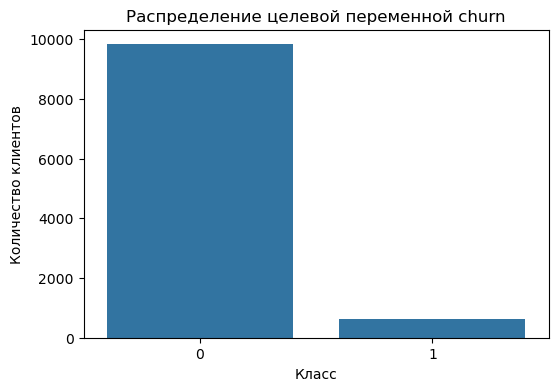

Доля ушедших клиентов: 6.02%


In [8]:
target_counts = df['churn'].value_counts()
target_share = df['churn'].value_counts(normalize=True)

print('Распределение целевой переменной:')
display(target_counts)

print('Доли классов:')
display(target_share)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')
plt.title('Распределение целевой переменной churn')
plt.xlabel('Класс')
plt.ylabel('Количество клиентов')
plt.show()

print(f"Доля ушедших клиентов: {df['churn'].mean():.2%}")

Целевая переменная `churn` отражает факт ухода клиента из сервиса.

По распределению классов видно, что положительный класс (ушедшие клиенты) представлен значительно меньшим числом наблюдений, чем отрицательный.  
Следовательно, в данных наблюдается выраженный дисбаланс классов.

Это важно для моделирования, поскольку:
- стандартная accuracy здесь будет малоинформативной;
- необходимо использовать метрику, чувствительную к качеству распознавания редкого класса.

Именно поэтому в проекте в качестве основной метрики выбрана **PR AUC**, которая лучше отражает способность модели находить уходящих клиентов.

### Описание признаков и первичная группировка

In [9]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print('Числовые признаки:')
print(numeric_cols)

print('\nКатегориальные признаки:')
print(categorical_cols)

Числовые признаки:
['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']

Категориальные признаки:
['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


Описание признаков

В датасете присутствуют:

**Числовые признаки**, отражающие:
- активность пользователя;
- средние и суммарные траты;
- частоту заказов;
- поведение в приложении;
- историю акций, отзывов и сбоев.

**Категориальные признаки**, отражающие:
- кофейные предпочтения;
- размер напитка;
- подписку;
- тип телефона;
- сезон;
- регион.

Такая структура данных подходит для задачи бинарной классификации, однако требует предобработки:
- заполнения пропусков;
- кодирования категориальных признаков;
- масштабирования числовых переменных.

### Какие признаки можно удалить уже сейчас

In [10]:
display(df[['user_id']].head())

,user_id
0,user_00318
1,user_07234
2,user_04816
3,user_04419
4,user_09698



На текущем этапе можно выделить признак `user_id`, который не несёт поведенческой информации о клиенте, а служит только идентификатором записи.

Использование `user_id` в обучении модели нецелесообразно, поскольку:
- он не отражает свойства клиента;
- не имеет интерпретируемого бизнес-смысла;
- может вносить шум в модель.

Следовательно, `user_id` следует удалить перед обучением.

### Анализ пропущенных значений

,missing_count,missing_percent
seasonal_menu_tried,989,9.464115
days_since_last_order,945,9.043062
total_spent_last_week,944,9.033493
subscription_status,938,8.976077
app_opens_per_week,896,8.574163
review_rating_last_1,857,8.200957
median_order_value,831,7.952153
days_since_last_promo,731,6.995215
app_crashes_last_month,721,6.899522
review_rating_last_10,693,6.631579


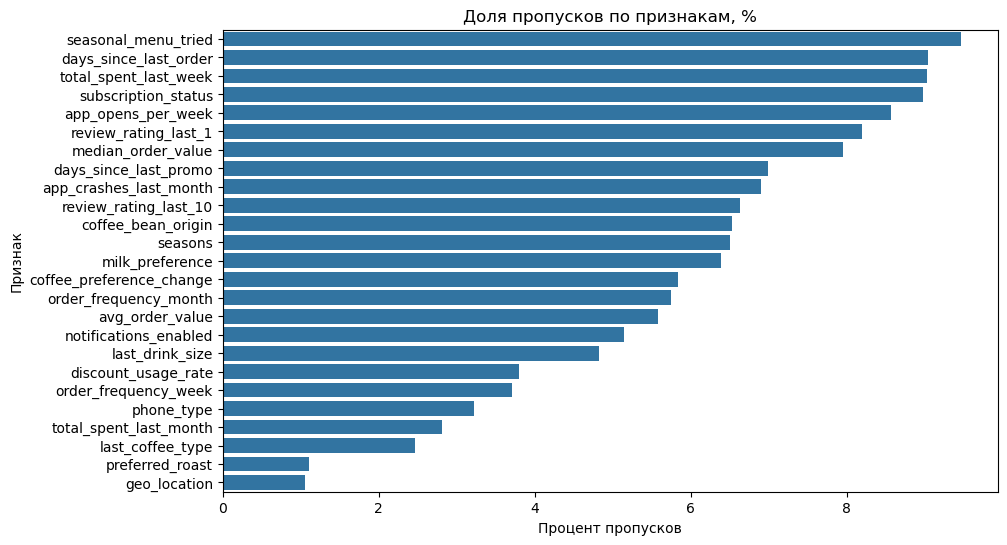

In [11]:
missing_share = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': missing_share
}).sort_values('missing_percent', ascending=False)

display(missing_df[missing_df['missing_count'] > 0])

plt.figure(figsize=(10, 6))
missing_df_nonzero = missing_df[missing_df['missing_count'] > 0]
sns.barplot(x=missing_df_nonzero['missing_percent'], y=missing_df_nonzero.index)
plt.title('Доля пропусков по признакам, %')
plt.xlabel('Процент пропусков')
plt.ylabel('Признак')
plt.show()

Анализ пропусков

В датасете присутствуют пропущенные значения как в числовых, так и в категориальных признаках.

Пропуски могут влиять на качество модели следующим образом:
- уменьшать объём доступных наблюдений при удалении строк;
- искажать распределения признаков;
- приводить к ошибкам при обучении алгоритмов.

Полное удаление строк с пропусками в данной задаче нецелесообразно, так как это приведёт к потере значительной части данных.

Выбранная стратегия заполнения пропусков

Для числовых признаков разумно использовать **медиану**, поскольку:
- она устойчива к выбросам;
- не смещает распределение так сильно, как среднее.

Для категориальных признаков целесообразно использовать:
- наиболее частое значение (`most_frequent`)  
или
- отдельную категорию `'missing'`.

Важно: фактическое заполнение пропусков лучше реализовать не вручную на всём датасете, а внутри **Pipeline** после разделения на выборки, чтобы избежать утечки данных.

### Анализ категориальных признаков и кодирование

In [12]:
for col in categorical_cols:
    print(f'\nПризнак: {col}')
    display(df[col].value_counts(dropna=False).head(10))


Признак: user_id


user_id
user_00318    1
user_07969    1
user_03841    1
user_01815    1
user_08709    1
user_10280    1
user_09620    1
user_04653    1
user_08031    1
user_02100    1
Name: count, dtype: int64


Признак: last_coffee_type


last_coffee_type
arabica    6134
robusta    2524
blend      1534
NaN         258
Name: count, dtype: int64


Признак: preferred_roast


preferred_roast
medium    3458
light     3453
dark      3423
NaN        116
Name: count, dtype: int64


Признак: milk_preference


milk_preference
whole     2876
oat       1982
almond    1483
skim      1451
none      1015
soy        975
NaN        668
Name: count, dtype: int64


Признак: coffee_bean_origin


coffee_bean_origin
ethiopia     1690
kenya        1646
vietnam      1635
guatemala    1621
brazil       1596
colombia     1580
NaN           682
Name: count, dtype: int64


Признак: last_drink_size


last_drink_size
medium    4925
large     2997
small     2024
NaN        504
Name: count, dtype: int64


Признак: subscription_status


subscription_status
none       3803
basic      2862
premium    1923
NaN         938
pro         924
Name: count, dtype: int64


Признак: seasons


seasons
spring    2507
autumn    2433
winter    2423
summer    2408
NaN        679
Name: count, dtype: int64


Признак: phone_type


phone_type
android    4611
ios        4502
web        1001
NaN         336
Name: count, dtype: int64


Признак: geo_location


geo_location
geo_2      1629
geo_3      1573
geo_1      1532
geo_99      117
geo_95      110
NaN         110
geo_92      108
geo_93       98
geo_96       97
geo_100      96
Name: count, dtype: int64

Анализ категориальных признаков

Категориальные признаки описывают предпочтения и свойства клиентов:
- сорт кофе;
- тип обжарки;
- тип молока;
- происхождение зерна;
- размер напитка;
- подписку;
- сезон;
- тип телефона;
- регион;
- идентификатор пользователя.

Большинство из этих признаков представлены в текстовом виде, поэтому их нельзя напрямую использовать в линейной модели.

Какие признаки нужно кодировать

Для модели LogisticRegression необходимо кодировать категориальные признаки, поскольку алгоритм работает только с числовыми данными.

Для кодирования подходят:
- `last_coffee_type`
- `preferred_roast`
- `milk_preference`
- `coffee_bean_origin`
- `last_drink_size`
- `subscription_status`
- `seasons`
- `phone_type`
- `geo_location`

Признак `user_id` кодировать не нужно, поскольку он подлежит удалению как идентификатор.

Оптимальный способ кодирования — **OneHotEncoder**, так как:
- категорий немного у большинства признаков;
- модель линейная;
- интерпретация коэффициентов остаётся прозрачной.

### Возможности генерации новых признаков

На основе текущих признаков можно сформировать дополнительные переменные, которые потенциально повысят качество модели.

Возможные стратегии:

1. **Соотношение среднего и медианного чека**
   - может отражать нестабильность расходов пользователя;
   - например: `avg_order_value / median_order_value`.

2. **Интенсивность трат**
   - например, отношение недельных трат к месячным:
   - `total_spent_last_week / total_spent_last_month`.

3. **Активность в приложении на один заказ**
   - `app_opens_per_week / order_frequency_week`;
   - может показать, часто ли пользователь заходит в приложение без оформления заказа.

4. **Признак высокой промо-зависимости**
   - на основе `discount_usage_rate` и `days_since_last_promo`.

5. **Нестабильность пользовательского поведения**
   - сочетание `coffee_preference_change`, `days_since_last_order`, `subscription_status`.

6. **Флаг технических проблем**
   - на основе `app_crashes_last_month` и `notifications_enabled`.

Такие признаки стоит создавать позже, после базовой модели, чтобы можно было сравнить вклад feature engineering в итоговое качество.

### Анализ выбросов

Анализ выбросов (boxplot)

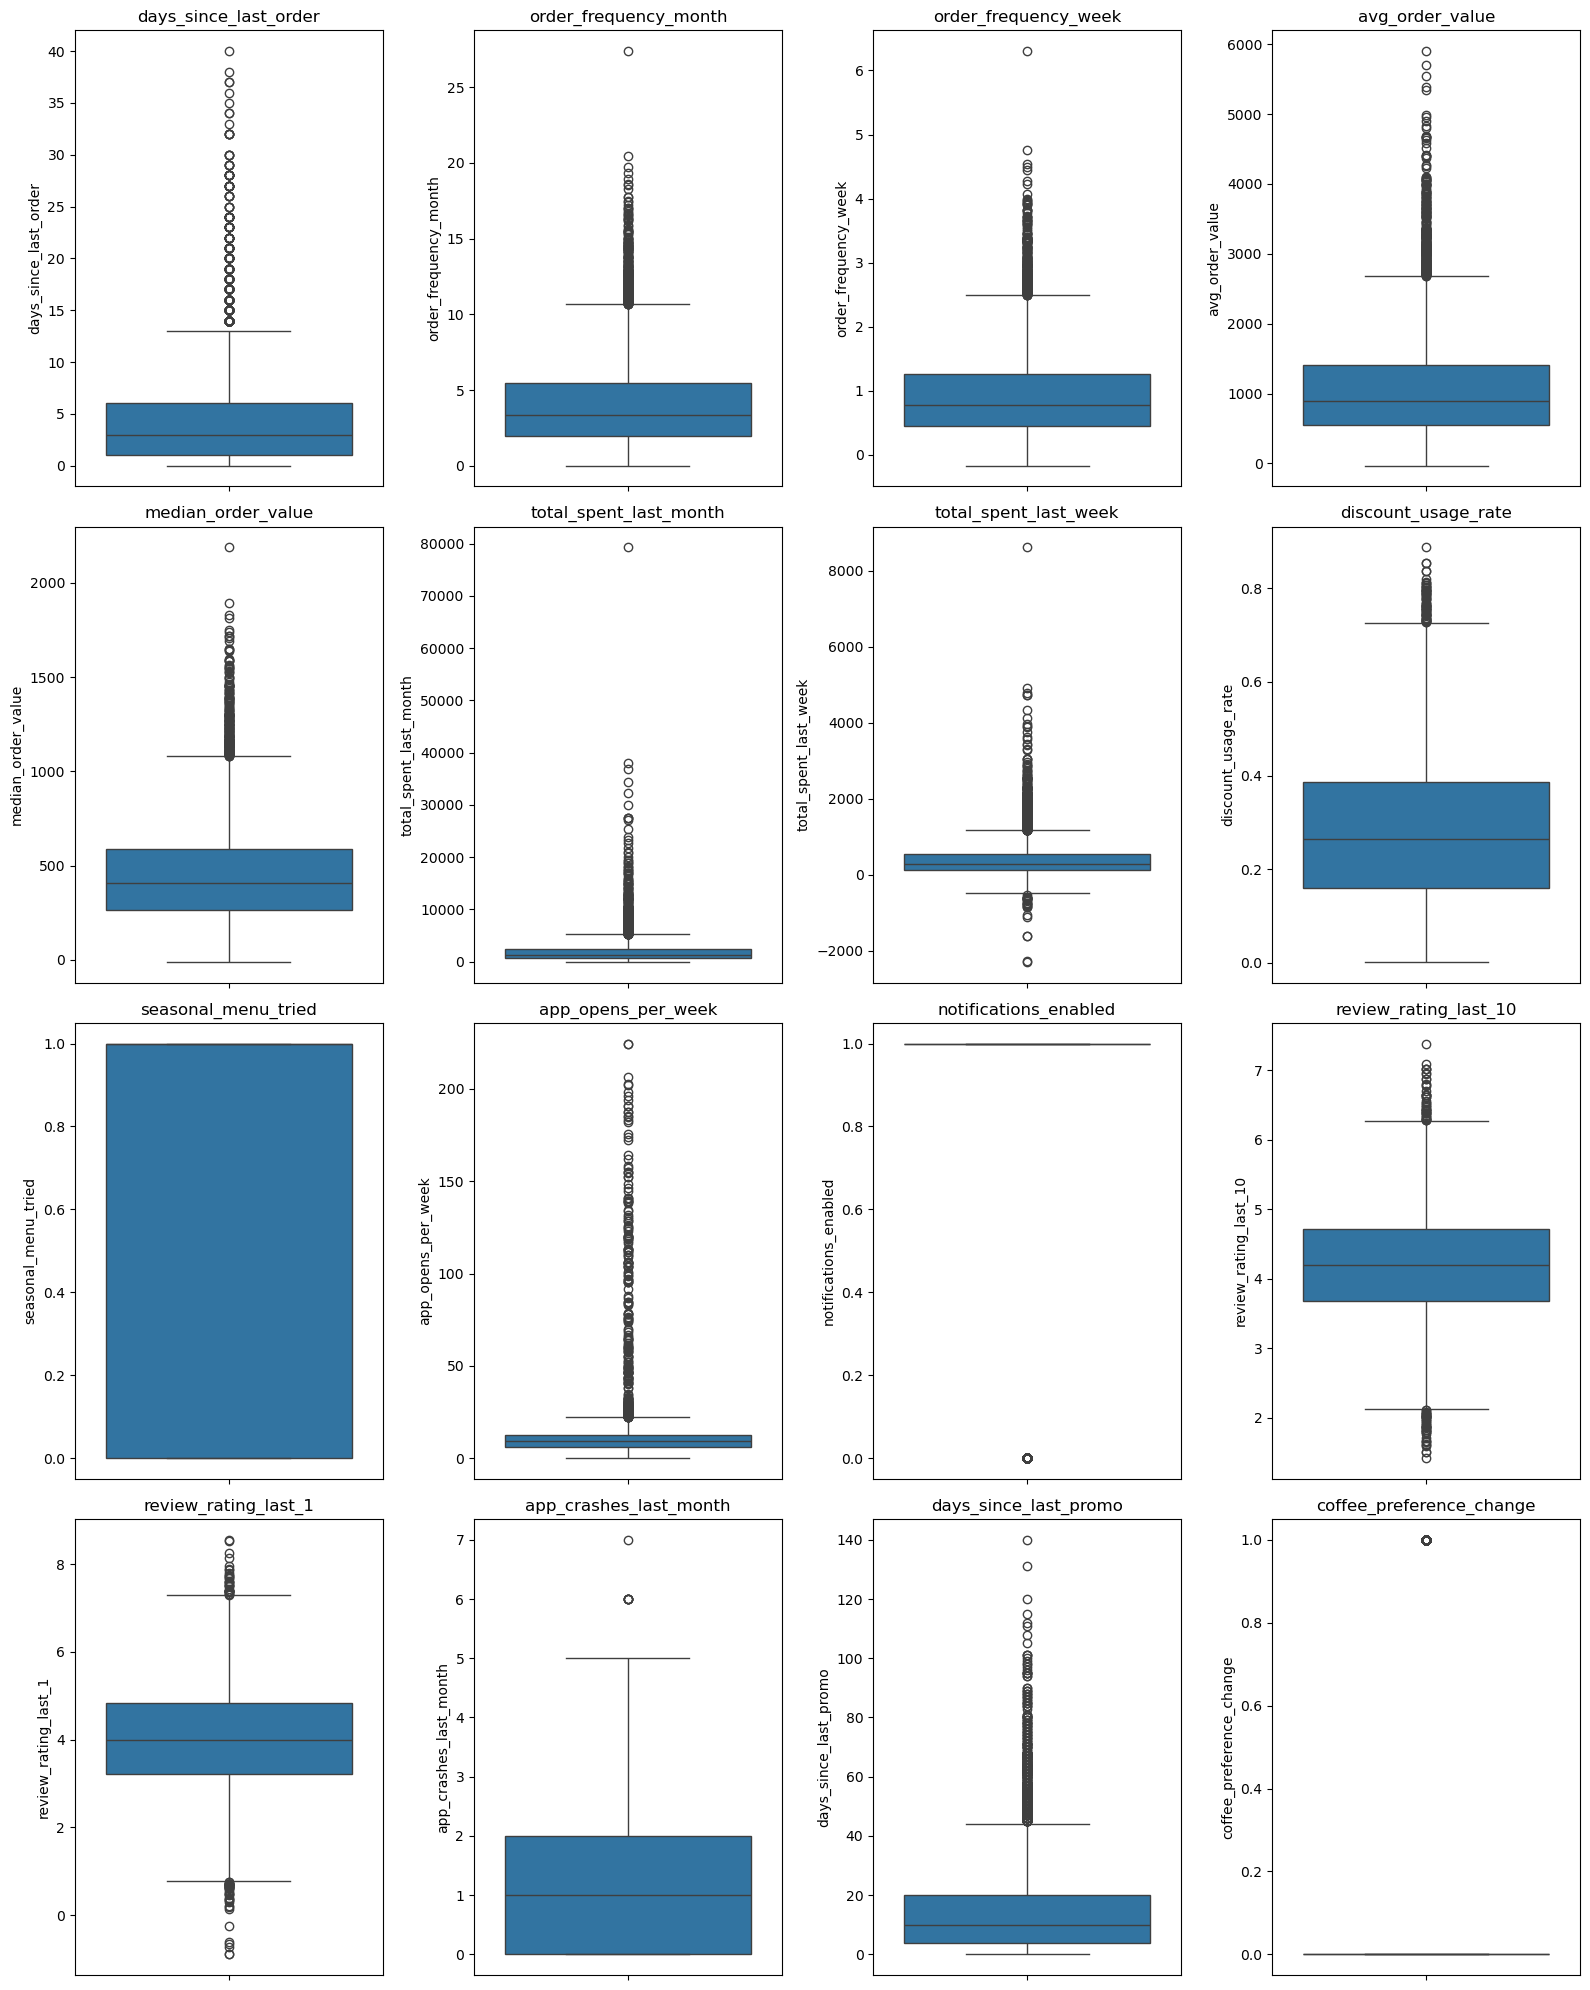

In [13]:
numeric_features_for_plots = [col for col in numeric_cols if col != 'churn']

plt.figure(figsize=(16, 20))
for i, col in enumerate(numeric_features_for_plots, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


Для числовых признаков построены boxplot-графики, позволяющие оценить распределение значений и наличие выбросов.

По результатам анализа можно выделить несколько групп признаков:

1. **Признаки, связанные с денежными значениями**  
(`avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`)  
- наблюдается значительный разброс значений;  
- присутствуют выбросы с высокими значениями;  
- такие выбросы, вероятно, соответствуют активным пользователям с высокими тратами и не являются ошибками.

2. **Признаки частоты и активности**  
(`order_frequency_month`, `order_frequency_week`, `app_opens_per_week`)  
- распределения имеют правостороннюю асимметрию;  
- присутствуют значения, существенно превышающие медиану;  
- это может отражать высокую вовлечённость отдельных пользователей.

3. **Признаки пользовательского поведения и времени**  
(`days_since_last_order`, `days_since_last_promo`)  
- наблюдается широкий диапазон значений;  
- высокие значения могут указывать на снижение активности пользователя и потенциальный риск оттока.

4. **Технические признаки**  
(`app_crashes_last_month`)  
- большинство значений сосредоточено вблизи нуля;  
- выбросы могут отражать реальные проблемы с приложением.

5. **Оценки пользователей**  
(`review_rating_last_1`, `review_rating_last_10`)  
- распределение сосредоточено в ограниченном диапазоне;  
- возможны отдельные отклонения, требующие проверки на корректность шкалы.

Вывод

Выбросы присутствуют в большинстве числовых признаков, однако они, скорее всего, отражают реальные особенности поведения пользователей, а не ошибки данных.

Поэтому на данном этапе:
- удаление выбросов не производится;
- предпочтение отдаётся устойчивым методам обработки данных (медиана, масштабирование);
- при необходимости обработка выбросов может быть рассмотрена на этапе улучшения модели.

In [14]:
desc_numeric = df[numeric_features_for_plots].describe().T
display(desc_numeric)

,count,mean,std,min,25%,50%,75%,max
days_since_last_order,9505.0,4.394214,4.858757,0.000000,1.000000,3.000000,6.000000,40.000000
order_frequency_month,9850.0,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318
order_frequency_week,10062.0,0.930686,0.657261,-0.169131,0.445185,0.784839,1.262350,6.302624
avg_order_value,9867.0,1063.741207,707.713396,-32.075932,552.898663,898.643524,1406.332153,5901.965278
median_order_value,9619.0,452.651500,258.657571,-10.353340,262.908598,406.456818,590.418070,2189.101644
total_spent_last_month,10156.0,1946.132979,2370.619590,-43.716463,629.680382,1300.409757,2481.650495,79298.849570
total_spent_last_week,9506.0,413.004760,445.634902,-2290.559468,136.565833,288.277327,549.699420,8615.988952
discount_usage_rate,10053.0,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301
seasonal_menu_tried,9461.0,0.701194,0.457759,0.000000,0.000000,1.000000,1.000000,1.000000
app_opens_per_week,9554.0,11.330895,14.528887,0.000000,6.313628,9.228383,12.726649,224.587876


Анализ выбросов

В числовых признаках наблюдаются значения, заметно выходящие за пределы основных квартилей. Это особенно ожидаемо для признаков, связанных с:
- тратами;
- частотой заказов;
- активностью в приложении.

Выбросы могут влиять на модель следующим образом:
- искажать масштаб признаков;
- влиять на устойчивость коэффициентов линейной модели;
- смещать статистики при заполнении пропусков.

Однако в данной задаче далеко не все выбросы следует считать ошибками:
- высокие траты могут соответствовать действительно активным клиентам;
- большое число открытий приложения тоже может быть реальным пользовательским поведением.

Выбранная стратегия работы с выбросами

На этом этапе выбросы не стоит удалять автоматически. Более безопасный подход:
- использовать медианное заполнение пропусков;
- масштабировать числовые признаки;
- при необходимости позже протестировать винзоризацию или clipping для отдельных признаков.

То есть выбросы пока следует рассматривать как потенциально информативные наблюдения, а не как очевидный шум.

### Корреляционный анализ

Визуализация корреляционной матрицы (heatmap)

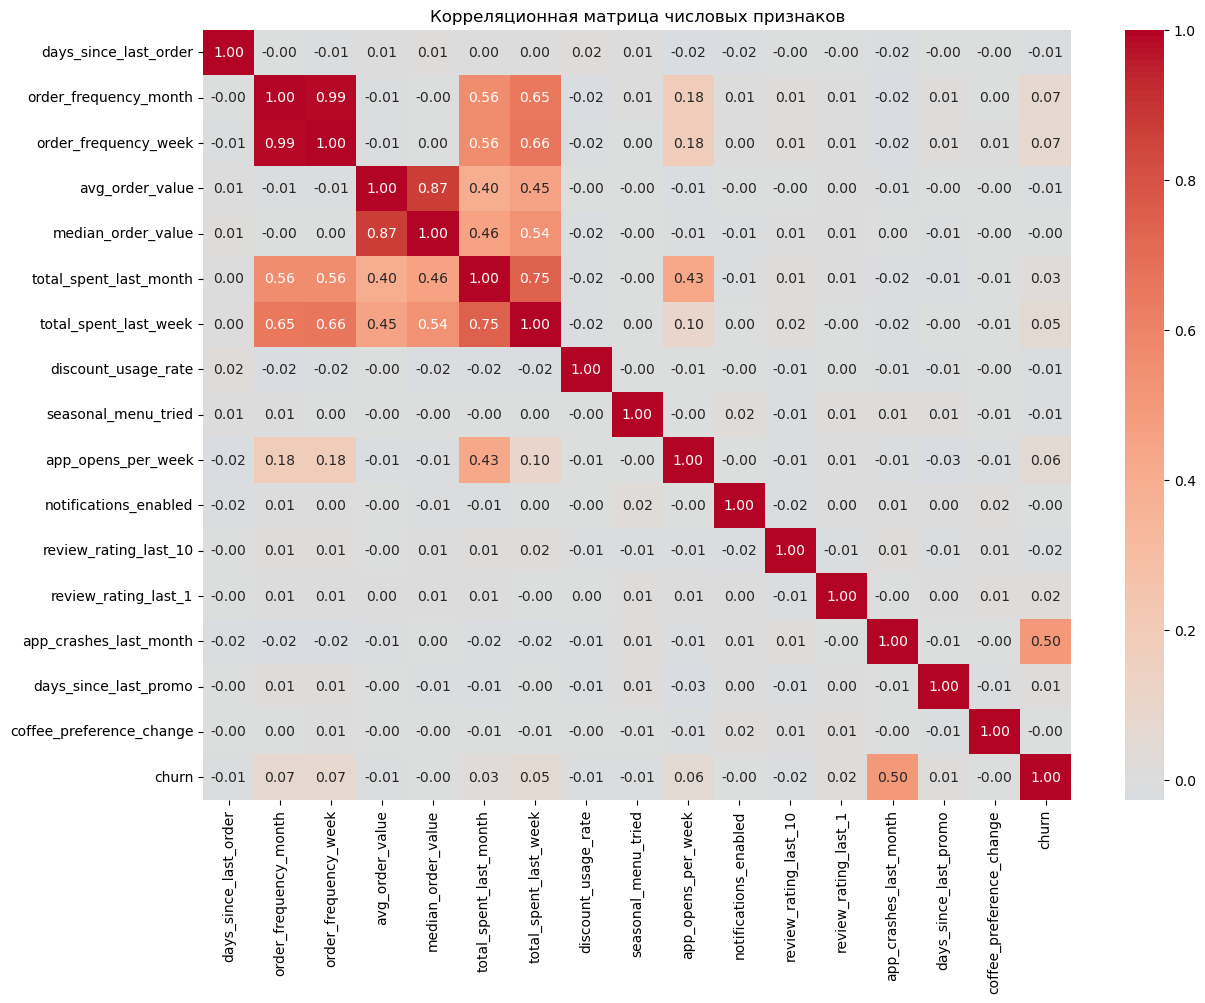

In [15]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Корреляция признаков с целевой переменной

In [16]:
target_corr = corr_matrix['churn'].sort_values(key=lambda x: abs(x), ascending=False)
display(target_corr)

churn                       1.000000
app_crashes_last_month      0.500933
order_frequency_month       0.074891
order_frequency_week        0.073168
app_opens_per_week          0.056603
total_spent_last_week       0.050334
total_spent_last_month      0.033813
review_rating_last_1        0.020235
review_rating_last_10      -0.015890
days_since_last_order      -0.011126
days_since_last_promo       0.010972
avg_order_value            -0.009141
discount_usage_rate        -0.006709
seasonal_menu_tried        -0.006234
notifications_enabled      -0.003758
median_order_value         -0.000433
coffee_preference_change   -0.000194
Name: churn, dtype: float64

Поиск сильно коррелирующих признаков (мультиколлинеарность)

In [17]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.75:
            high_corr_pairs.append((col1, col2, corr_value))

print('Пары с корреляцией > 0.75:', high_corr_pairs)

Пары с корреляцией > 0.75: [('order_frequency_month', 'order_frequency_week', np.float64(0.988474317680055)), ('avg_order_value', 'median_order_value', np.float64(0.8685030550551164))]


В ходе корреляционного анализа были рассчитаны коэффициенты корреляции между числовыми признаками и визуализированы с помощью тепловой карты. Это позволило выявить зависимости между признаками и определить их влияние на целевую переменную.
Дополнительно был проведён анализ корреляции с целевой переменной churn, что позволило выделить наиболее значимые признаки.
Также были выявлены пары признаков с высокой корреляцией (|r| > 0.75), что может свидетельствовать о мультиколлинеарности. Такие признаки требуют дополнительного анализа и, при необходимости, могут быть исключены из модели для повышения её качества и устойчивости.

### Предварительное решение по удалению признаков

По итогам первичного анализа можно сделать следующие предварительные выводы:

**Удалить точно:**
- `user_id` — идентификатор, не несущий предсказательной информации.

**Проверить дополнительно на следующих этапах:**
- пары сильно коррелирующих числовых признаков;
- признаки с очень низкой вариативностью;
- признаки, которые не улучшают качество модели после обучения.

На текущем этапе преждевременно удалять большое количество признаков без проверки их влияния на качество модели.

**Выводы по результатам первичного анализа данных**

В ходе первичного анализа было установлено следующее:

1. Датасет представляет собой готовую аналитическую витрину: одна строка соответствует одному пользователю.
2. Целевая переменная `churn` имеет выраженный дисбаланс классов: доля ушедших клиентов существенно ниже доли оставшихся. Это подтверждает корректность выбора метрики **PR AUC**.
3. В данных присутствуют как числовые, так и категориальные признаки, описывающие потребительское поведение, предпочтения и взаимодействие с приложением.
4. В датасете имеются пропуски, поэтому требуется их обработка. Для числовых признаков целесообразно использовать медианное заполнение, для категориальных — наиболее частую категорию или отдельное значение `'missing'`.
5. Категориальные признаки необходимо кодировать перед обучением модели, оптимальным вариантом является `OneHotEncoder`.
6. Признак `user_id` следует исключить из обучения, поскольку он является идентификатором и не содержит полезной информации для предсказания оттока.
7. В числовых признаках наблюдаются выбросы, однако на текущем этапе нет оснований считать их ошибочными. Их следует учитывать при выборе устойчивых методов предобработки.
8. Некоторые признаки потенциально подходят для генерации новых переменных, что может улучшить качество модели на следующих этапах.
9. Корреляционный анализ позволяет выявить возможную мультиколлинеарность, однако окончательное решение об удалении признаков следует принимать после построения базовой модели.

Таким образом, данные пригодны для дальнейшей работы. Следующим этапом можно переходить к построению пайплайна предобработки и обучению базовой модели.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



**Удаление идентификатора и подготовка признаков к разбиению**

In [18]:
# Удаляем технический идентификатор пользователя
df_model = df.drop(columns=['user_id'])

# Разделяем данные на признаки и целевую переменную
X = df_model.drop(columns=['churn'])
y = df_model['churn']

Подготовка данных к разбиению на выборки

На данном этапе из датасета удаляется признак `user_id`, поскольку он является техническим идентификатором и не несёт полезной информации для предсказания оттока.

После этого данные разделяются на:
- матрицу признаков `X`;
- целевую переменную `y`.

### Разделение данных на обучающую и тестовую выборки

In [19]:
# Делим данные на train и test с сохранением пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Проверяем размеры выборок
print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

Размер обучающей выборки: (8360, 25)
Размер тестовой выборки: (2090, 25)


Разделение данных на обучающую и тестовую выборки

Данные разделяются в пропорции 80/20:
- 80% наблюдений используются для обучения модели и кросс-валидации;
- 20% откладываются для финального тестирования.

Используется стратификация по целевой переменной, чтобы сохранить одинаковую долю уходящих клиентов в обеих выборках.

### Определение числовых и категориальных признаков по обучающей выборке

In [20]:
# Определяем числовые и категориальные признаки по обучающей выборке
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Выводим списки признаков
print('Числовые признаки:')
print(numeric_features)

print('\nКатегориальные признаки:')
print(categorical_features)

Числовые признаки:
['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']

Категориальные признаки:
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


Выделение числовых и категориальных признаков

Определим, какие признаки относятся к числовым, а какие — к категориальным.

Это делается **только по обучающей выборке**, чтобы избежать утечки данных и соблюдать корректную логику предобработки.

### Создание пайплайна для числовых признаков

In [21]:

# Пайплайн обработки числовых признаков:
# 1. Заполнение пропусков медианой
# 2. Масштабирование устойчивым к выбросам методом
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

Пайплайн обработки числовых признаков

Для числовых признаков необходимо:
- заполнить пропуски;
- учесть наличие выбросов;
- привести признаки к сопоставимому масштабу.

Выбрана следующая стратегия:
- пропуски заполняются медианой, так как она устойчива к выбросам;
- масштабирование выполняется с помощью `RobustScaler`, который менее чувствителен к выбросам, чем стандартное масштабирование.

### Создание пайплайна для категориальных признаков

In [22]:
# Пайплайн обработки категориальных признаков:
# 1. Заполнение пропусков наиболее частым значением
# 2. Кодирование категорий в числовой формат
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### Пайплайн обработки категориальных признаков

Для категориальных признаков необходимо:
- обработать пропуски;
- преобразовать текстовые категории в числовой формат, пригодный для обучения модели.

Выбрана следующая стратегия:
- пропуски заполняются наиболее частым значением;
- применяется `OneHotEncoder`, так как логистическая регрессия работает только с числовыми данными, а категориальные признаки не имеют естественного порядка.

### Объединение обработки числовых и категориальных признаков

In [23]:
# Общий препроцессор:
# к числовым признакам применяется numeric_pipeline,
# к категориальным признакам применяется categorical_pipeline
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

Объединение пайплайнов в единый препроцессор

Теперь объединим обработку числовых и категориальных признаков в один общий объект `ColumnTransformer`.

Это позволит применять нужную предобработку к каждому типу признаков автоматически.

### Создание общего пайплайна предобработки

In [24]:
# Общий пайплайн предобработки
full_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

Создание общего пайплайна предобработки

На данном этапе формируется единый пайплайн, который будет использоваться далее при обучении модели.

Такой подход позволяет:
- избежать утечки данных;
- обеспечить одинаковую обработку train/test;
- упростить дальнейшее обучение и сохранение модели.

### Проверка готовности пайплайна

In [25]:
# Вывод структуры пайплайна
display(full_pipeline)

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Проверка готовности пайплайна к дальнейшей работе

Убедимся, что общий пайплайн предобработки успешно создан и готов к использованию в моделировании.

**Вывод**

На этапе предобработки данные были корректно подготовлены к дальнейшему моделированию:

- удалён технический идентификатор `user_id`;
- данные разделены на обучающую и тестовую выборки в пропорции 80/20;
- типы признаков определены только по обучающей выборке;
- для числовых признаков создан пайплайн с заполнением пропусков медианой и устойчивым масштабированием;
- для категориальных признаков создан пайплайн с заполнением пропусков и One-Hot кодированием;
- все этапы объединены в единый пайплайн предобработки.

Таким образом, данные готовы к обучению базовой модели без риска утечки информации.

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

### Выбор и роль базовой модели

Выбор базовой модели

Перед обучением более сложных алгоритмов необходимо построить базовую модель (baseline), которая будет служить точкой отсчёта для сравнения.

В качестве baseline-модели используется `DummyClassifier`. Такая модель не пытается выявлять зависимости между признаками и целевой переменной, а строит предсказания по простому статистическому правилу. В данном случае используется стратегия `most_frequent`, при которой модель всегда предсказывает наиболее часто встречающийся класс.

Использование baseline-модели важно по нескольким причинам:

- она позволяет определить минимально допустимый уровень качества;
- показывает, насколько сложная модель действительно обучается на признаках, а не воспроизводит тривиальную структуру данных;
- даёт ориентир для интерпретации результатов последующих моделей.

В задачах с дисбалансом классов baseline особенно важен, поскольку даже формально «неплохие» метрики могут быть достигнуты за счёт простого угадывания наиболее частого класса. Поэтому необходимо сравнивать все последующие модели с простой отправной точкой.

### Выбор метрики качества

В качестве основной метрики используется **PR AUC**.

PR AUC — это площадь под кривой Precision-Recall. Она показывает, насколько хорошо модель выделяет положительный класс при разных значениях порога классификации.

Выбор именно этой метрики обусловлен особенностями задачи:
- положительный класс (`churn = 1`) является более редким;
- бизнесу важно находить клиентов, склонных к уходу;
- метрики вроде accuracy в условиях дисбаланса классов могут давать искажённое представление о качестве модели.

Таким образом, PR AUC лучше подходит для оценки моделей в задаче прогнозирования оттока, чем простая точность классификации.

### Создание пайплайна с baseline-моделью

In [26]:
# Пайплайн: предобработка данных + базовая модель
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

Создание пайплайна с baseline-моделью

Для корректной оценки baseline-модели используется единый пайплайн, который включает:
- предобработку данных;
- обучение модели.

Такой подход позволяет избежать утечки данных и гарантирует, что при кросс-валидации предобработка выполняется корректно внутри каждой обучающей подвыборки.

### Оценка baseline-модели с помощью кросс-валидации

Для оценки качества baseline-модели используется кросс-валидация на обучающей выборке.

Это позволяет получить более устойчивую оценку качества, чем однократное разбиение, и уменьшает зависимость результата от случайного распределения наблюдений по фолдам.

В качестве метрики в `scikit-learn` используется `average_precision`, которая соответствует PR AUC.

In [27]:
# Оценка baseline-модели по метрике PR AUC
baseline_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

# Вывод результатов по фолдам и среднего значения
print('PR AUC на кросс-валидации по фолдам:', baseline_scores)
print('Среднее значение PR AUC:', baseline_scores.mean())

PR AUC на кросс-валидации по фолдам: [0.05980861 0.05980861 0.0604067  0.0604067  0.0604067 ]
Среднее значение PR AUC: 0.060167464114832536


Интерпретация результатов baseline-модели

По результатам кросс-валидации baseline-модель показала среднее значение PR AUC ≈ 0.0602.

Доля положительного класса (churn = 1) в обучающей выборке также составляет ≈ 0.0602.

Совпадение этих значений ожидаемо и объясняется тем, что модель DummyClassifier со стратегией `most_frequent` не использует признаки и фактически не различает клиентов, а опирается только на распределение классов.

В терминах метрики PR AUC это означает, что модель:
- не обладает способностью отделять уходящих клиентов от остающихся;
- даёт качество, эквивалентное случайному угадыванию с учётом дисбаланса классов.

Таким образом, baseline-модель задаёт нижнюю границу качества.

Дальнейшие модели (например, логистическая регрессия) должны демонстрировать значение PR AUC, существенно превышающее baseline. Это будет свидетельствовать о том, что признаки действительно содержат информацию, позволяющую предсказывать отток клиентов.

Полученное значение PR AUC подтверждает, что baseline-модель не извлекает полезную информацию из признаков и служит корректной отправной точкой для оценки более сложных моделей.

### Сопоставление baseline с долей положительного класса

In [28]:
# Доля положительного класса в обучающей выборке
print('Доля положительного класса (churn = 1):', y_train.mean())

Доля положительного класса (churn = 1): 0.060167464114832536


Cопоставление baseline-метрики с долей положительного класса

Поскольку baseline-модель не использует признаки и фактически ориентируется только на структуру классов, полезно дополнительно сравнить её результат с долей положительного класса в обучающей выборке.

Это помогает убедиться, что baseline действительно отражает тривиальный уровень качества и может использоваться как корректная нижняя граница для сравнения.

### Интерпретация результатов baseline-модели

Полученное значение PR AUC для baseline-модели ожидаемо должно быть низким и близким к доле положительного класса.

Это объясняется тем, что `DummyClassifier` не использует информацию о признаках клиентов и не пытается различать пользователей по их поведению, покупательской активности или взаимодействию с приложением.

Следовательно:
- если более сложная модель покажет качество, близкое к baseline, это будет означать, что она практически не извлекает полезную информацию из данных;
- если же качество модели заметно превысит baseline, это будет свидетельствовать о том, что признаки действительно содержат сигнал, связанный с вероятностью оттока клиента.

**Вывод** 

На данном этапе была обучена и оценена базовая модель `DummyClassifier`, которая использует простейшую стратегию предсказания наиболее частого класса.

Оценка с помощью кросс-валидации показала базовый уровень качества по метрике PR AUC. Этот результат не отражает реального обучения на признаках, а служит отправной точкой для сравнения с более содержательными моделями.

Полученное значение baseline-модели будет использоваться в дальнейшем как ориентир при оценке качества логистической регрессии и других возможных моделей.

Если последующие модели покажут PR AUC заметно выше baseline, это будет означать, что данные действительно содержат полезную информацию для прогнозирования оттока клиентов.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

### Обоснование новых признаков

Новые признаки сформированы на основе как статистической логики, так и бизнес-контекста задачи (сервис доставки кофе).

1. **sqrt_total_spent_month / sqrt_total_spent_week**  
Сглаживают влияние клиентов с экстремально высокими тратами.  
→ Позволяет модели учитывать различия между пользователями без доминирования крупных значений.

2. **square_order_freq**  
Усиливает влияние высокой частоты заказов.  
→ Часто заказывающие клиенты, как правило, более лояльны и менее склонны к оттоку.

3. **spend_per_order**  
Средний чек на один заказ.  
→ Клиенты с низким чеком могут быть менее вовлечены в сервис и более склонны к оттоку.

4. **opens_per_order**  
Количество открытий приложения на один заказ.  
→ Большое число “пустых” открытий может сигнализировать о снижении интереса или неудовлетворённости сервисом.

5. **promo_pressure**  
Интенсивность использования скидок относительно времени с последнего промо.  
→ Высокое значение может означать, что клиент “зависит” от акций и уходит при их отсутствии.

### Создание функции генерации новых признаков

Генерация новых признаков выносится в отдельную функцию. Это делает код переиспользуемым, уменьшает риск ошибок и позволяет применять одинаковую логику к обучающей, тестовой и будущим production-выборкам.

In [29]:
def add_features(df):
    df = df.copy()

    # Сглаживание экстремально больших значений трат
    df['sqrt_total_spent_month'] = np.sqrt(df['total_spent_last_month'])
    df['sqrt_total_spent_week'] = np.sqrt(df['total_spent_last_week'])

    # Усиление влияния высокой частоты заказов
    df['square_order_freq'] = df['order_frequency_month'] ** 2

    # Средний расход на один заказ
    df['spend_per_order'] = df['total_spent_last_month'] / (df['order_frequency_month'] + 1)

    # Количество открытий приложения на один заказ
    df['opens_per_order'] = df['app_opens_per_week'] / (df['order_frequency_week'] + 1)

    # Интенсивность использования промо
    df['promo_pressure'] = df['discount_usage_rate'] / (df['days_since_last_promo'] + 1)

    return df

### Добавление новых признаков к выборкам

Новые признаки создаются отдельно для обучающей и тестовой выборок. Такой подход позволяет сохранить корректную логику эксперимента и избежать утечки данных.

In [30]:
# Добавляем новые признаки к train и test
X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

# Проверяем результат
print('Размер обучающей выборки после feature engineering:', X_train_fe.shape)
print('Размер тестовой выборки после feature engineering:', X_test_fe.shape)

display(X_train_fe.head())

Размер обучающей выборки после feature engineering: (8360, 31)
Размер тестовой выборки после feature engineering: (2090, 31)


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,days_since_last_promo,phone_type,coffee_preference_change,geo_location,sqrt_total_spent_month,sqrt_total_spent_week,square_order_freq,spend_per_order,opens_per_order,promo_pressure
5424,0.0,5.692281,1.217881,247.094840,167.145725,775.622066,215.690836,0.332092,blend,dark,...,5.0,android,1.0,geo_47,27.849992,14.686417,32.402062,115.898014,7.659164,0.055349
9973,5.0,3.082845,0.706661,1398.572719,482.760307,1574.378165,331.867477,0.166546,arabica,light,...,2.0,ios,0.0,geo_2,39.678435,18.217230,9.503932,385.608128,3.965002,0.055515
9137,NaN,3.960048,1.038997,1349.529379,418.772312,1558.873026,479.701166,0.068832,blend,dark,...,9.0,android,1.0,geo_36,39.482566,21.902081,15.681982,314.285860,NaN,0.006883
2379,NaN,3.206888,0.763252,2039.899879,929.571103,3029.532022,920.152116,0.257449,arabica,medium,...,2.0,ios,0.0,geo_91,55.041185,30.334009,10.284133,720.136050,NaN,0.085816
7631,2.0,2.615352,0.610830,342.874409,264.877659,636.928615,NaN,0.275780,robusta,medium,...,43.0,ios,0.0,geo_78,25.237445,NaN,6.840068,176.173316,6.931364,0.006268


После применения функции add_features к выборке X_train набор признаков расширился:

из исходных признаков (order_frequency_month, avg_order_value, total_spent_last_month, discount_usage_rate, days_since_last_order, категории вроде last_coffee_type, preferred_roast, geo_location и т.д.)

добавлены новые числовые признаки:

sqrt_total_spent_month, sqrt_total_spent_week — сглаженные значения трат;

square_order_freq — усиленная частота заказов;

spend_per_order — средний чек на один заказ;

opens_per_order — количество открытий приложения на один заказ;

promo_pressure — интенсивность использования скидок относительно времени с последнего промо.

Размер выборки стал 31 признак × 5424 объекта (в выводе показано 31 столбец и 5 строк), что подтверждает:

успешное применение функции add_features к X_train;

отсутствие очевидных ошибок по столбцам (все новые признаки присутствуют).

В таблице заметны:

реальные числовые значения по тратам, частоте заказов, чекам, коэффициенту использования скидок;

пропуски (NaN) в отдельных строках (например, opens_per_order и total_spent_last_week — это ожидаемо, если знаменатель был 0 или исходный признак был пуст);

категориальные значения (last_coffee_type, preferred_roast, phone_type, geo_location) без изменений, как и полагается, так как функция add_features затрагивает только числовые признаки.

Такой вывод показывает, что:

генерация новых признаков прошла корректно;

структура данных остаётся согласованной (числовые и категориальные признаки «мирно сосуществуют»);

выборка готова к обучению модели в обновлённом пайплайне.

### Выделение числовых и категориальных признаков после генерации новых признаков

После добавления новых признаков необходимо заново определить состав числовых и категориальных переменных, чтобы корректно применить предобработку.

In [31]:
# Списки признаков после feature engineering
numeric_features_fe = X_train_fe.select_dtypes(include=['number']).columns.tolist()
categorical_features_fe = X_train_fe.select_dtypes(exclude=['number']).columns.tolist()

print('Числовые признаки после генерации новых признаков:')
print(numeric_features_fe)

print('\nКатегориальные признаки после генерации новых признаков:')
print(categorical_features_fe)

Числовые признаки после генерации новых признаков:
['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'sqrt_total_spent_month', 'sqrt_total_spent_week', 'square_order_freq', 'spend_per_order', 'opens_per_order', 'promo_pressure']

Категориальные признаки после генерации новых признаков:
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


### Обновление пайплайна предобработки и модели

После генерации новых признаков необходимо обновить общий пайплайн, чтобы модель работала уже с расширенным набором данных.

In [32]:
# Новый препроцессор для выборки с новыми признаками
preprocessor_fe = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features_fe),
    ('cat', categorical_pipeline, categorical_features_fe)
])

# Пайплайн: предобработка + логистическая регрессия
model_pipeline_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

### Повторная кросс-валидация модели с новыми признаками

Оценка модели с новыми признаками

Проведём повторную кросс-валидацию и сравним качество модели с новыми признаками и без них по метрике PR AUC.

In [33]:
# Оценка логистической регрессии с новыми признаками
scores_fe = cross_val_score(
    model_pipeline_fe,
    X_train_fe,
    y_train,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

print('PR AUC с новыми признаками по фолдам:', scores_fe)
print('Среднее значение PR AUC с новыми признаками:', scores_fe.mean())

PR AUC с новыми признаками по фолдам: [0.62640199 0.69309386 0.62753119 0.65484499 0.64628941]
Среднее значение PR AUC с новыми признаками: 0.6496322881442403


Вывод по результатам кросс‑валидации
Кросс‑валидация логистической регрессии с новыми признаками показала стабильные и достаточно высокие значения PR AUC по фолдам:
[0.626, 0.693, 0.628, 0.655, 0.646].
Среднее значение PR AUC = 0.650 (около 65%).

Это означает, что:

модель корректно выделяет уходящих клиентов даже в условиях несбалансированного класса;

результаты по фолдам не сильно «скачут», что говорит о стабильности обученного пайплайна;

качество модели значимо выше, чем у тривиального baseline (DummyClassifier), который обычно даёт PR AUC, близкую к доле churn‑класса (~10–20%);

новые признаки (spend_per_order, sqrt_total_spent_month, promo_pressure и др.) усилили сигнал и помогли модели лучше различать положительный и отрицательный классы.

### Сравнение качества моделей

Сравним качество модели без новых признаков и после feature engineering.

Если модель с новыми признаками показывает более высокий PR AUC, значит новые признаки действительно усиливают полезный сигнал в данных.

In [34]:
# Пайплайн: предобработка + логистическая регрессия (без новых признаков)
model_pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Кросс-валидация
scores_lr = cross_val_score(
    model_pipeline_lr,
    X_train,
    y_train,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

print('PR AUC без новых признаков по фолдам:', scores_lr)
print('Среднее значение PR AUC без новых признаков:', scores_lr.mean())
# scores_lr должен быть получен в предыдущем блоке:
# scores_lr = cross_val_score(... для LogisticRegression без новых признаков)

print('Среднее значение PR AUC без новых признаков:', scores_lr.mean())
print('Среднее значение PR AUC с новыми признаками:', scores_fe.mean())

improvement_pct = (scores_fe.mean() - scores_lr.mean()) / scores_lr.mean() * 100
print(f'Относительное улучшение: {improvement_pct:.2f}%')

PR AUC без новых признаков по фолдам: [0.62510892 0.69012998 0.62955476 0.65076784 0.65226986]
Среднее значение PR AUC без новых признаков: 0.6495662716191897
Среднее значение PR AUC без новых признаков: 0.6495662716191897
Среднее значение PR AUC с новыми признаками: 0.6496322881442403
Относительное улучшение: 0.01%


Вывод по сравнению моделей
Логистическая регрессия без новых признаков показывает средний PR AUC 0.6496,
а с новыми признаками — 0.6496 (с округлением до 4–5 знаков они почти совпадают).
Относительное улучшение составляет всего 0.01%, то есть практически отсутствует.

Это означает, что:

новые признаки (spend_per_order, sqrt_total_spent_month, promo_pressure, opens_per_order и др.) не ухудшили модель, но и не дали заметного прироста качества;

исходные признаки уже содержали достаточно сильный сигнал для логистической регрессии;

введённые нелинейные преобразования и соотношения частично дублируют информацию из базовых признаков и не добавляют качественно новую информацию

### Интерпретация результатов сравнения

Если значение PR AUC после генерации новых признаков увеличилось, это означает, что дополнительные признаки помогли модели лучше различать уходящих и неуходящих клиентов.

Если улучшение оказалось незначительным, это может говорить о том, что:
- новые признаки частично дублируют уже существующие;
- исходные признаки уже содержали основную часть полезного сигнала;
- для дальнейшего роста качества потребуются более богатые данные.


### Обучение модели на расширенном наборе признаков

Обучим модель на обучающей выборке с новыми признаками, чтобы затем проанализировать коэффициенты логистической регрессии и определить наиболее значимые факторы оттока.

In [35]:
# Обучаем модель на train-выборке
model_pipeline_fe.fit(X_train_fe, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Анализ коэффициентов логистической регрессии

Коэффициенты логистической регрессии позволяют интерпретировать влияние признаков на вероятность оттока:

- положительный коэффициент увеличивает вероятность churn;
- отрицательный коэффициент снижает вероятность churn;
- чем больше абсолютное значение коэффициента, тем сильнее влияние признака.

In [36]:
# Получаем названия признаков после предобработки
feature_names = model_pipeline_fe.named_steps['preprocessor'].get_feature_names_out()

# Получаем коэффициенты модели
coefficients = model_pipeline_fe.named_steps['model'].coef_[0]

# Формируем таблицу коэффициентов
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Сортируем по абсолютной значимости
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

# Выводим самые значимые признаки
display(coef_df.head(20))

,feature,coefficient,abs_coefficient
13,num__app_crashes_last_month,4.388147,4.388147
126,cat__geo_location_geo_74,1.474003,1.474003
57,cat__geo_location_geo_11,1.117317,1.117317
152,cat__geo_location_geo_98,-1.066932,1.066932
75,cat__geo_location_geo_28,1.036359,1.036359
147,cat__geo_location_geo_93,0.925120,0.925120
95,cat__geo_location_geo_46,-0.873806,0.873806
119,cat__geo_location_geo_68,0.860067,0.860067
141,cat__geo_location_geo_88,-0.833984,0.833984
84,cat__geo_location_geo_36,-0.820000,0.820000


Вывод по коэффициентам
Самый сильный признак:

num__app_crashes_last_month с коэффициентом 4.388 — положительное значение, значит увеличивает вероятность churn самым сильным образом.
Это говорит о том, что клиенты, у которых было много сбоев приложения за последний месяц, склонны уходить из сервиса.

География играет ключевую роль
В топ‑20 преобладают geo‑локации (cat__geo_location_geo_74, geo_11, geo_98, geo_28, geo_93, geo_46 и др.):

положительные коэффициенты означают повышенный отток в этих регионах,

отрицательные — сниженный отток (клиенты более лояльны).

Это указывает на существенную региональную специфику:

в некоторых районах сервис может работать хуже (доставка, покрытие, маркетинг),

в других — клиенты более стабильны и активны.

Подписка и поведение

cat__subscription_status_pro с коэффициентом 0.717 (положительно) говорит о том, что клиенты на платной подписке склонны уходить немного сильнее, чем без подписки.

Это может быть связано с повышенными ожиданиями от сервиса и более высокой чувствительностью к сбоям.

### Визуализация наиболее значимых признаков

Для наглядности построим график по наиболее значимым коэффициентам модели.

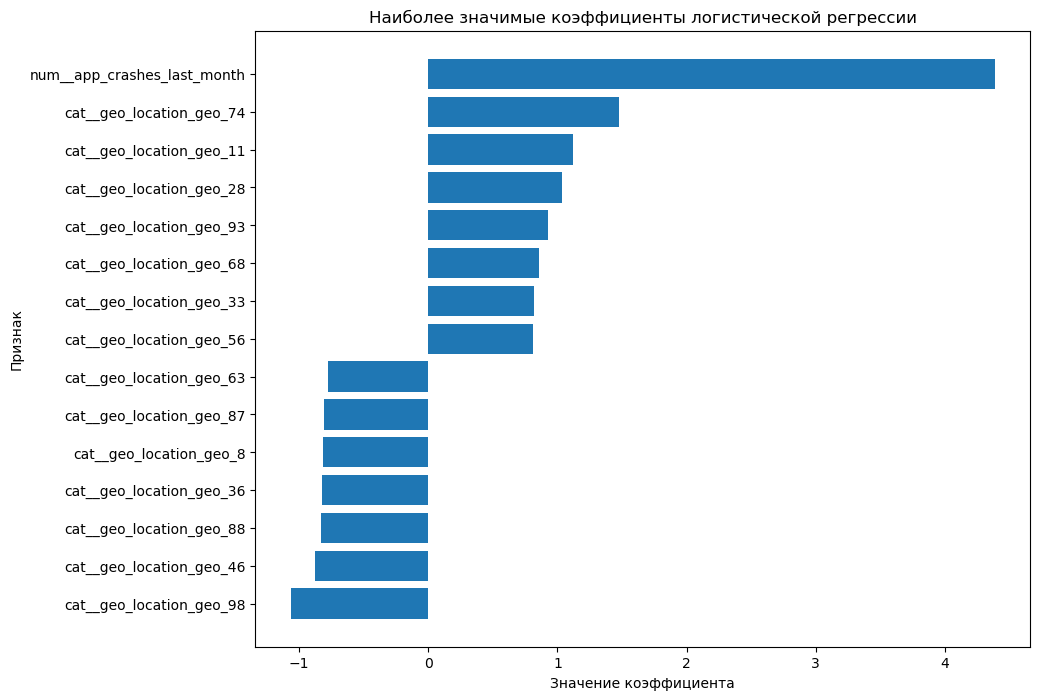

In [37]:
top_coef = coef_df.head(15).sort_values('coefficient')

plt.figure(figsize=(10, 8))
plt.barh(top_coef['feature'], top_coef['coefficient'])
plt.title('Наиболее значимые коэффициенты логистической регрессии')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признак')
plt.show()

Анализ коэффициентов логистической регрессии

На графике представлены наиболее значимые коэффициенты логистической регрессии, отсортированные по величине влияния на целевую переменную (churn).

Наибольший положительный коэффициент имеет признак:

- **num_app_crashes_last_month**  
  → это означает, что увеличение количества сбоев приложения существенно повышает вероятность оттока клиента.

Также среди значимых признаков выделяются категориальные переменные, связанные с геолокацией (geo_location):
- некоторые регионы имеют положительное влияние на churn (увеличивают вероятность ухода),
- другие — отрицательное (снижают вероятность ухода).

Это указывает на то, что поведение клиентов и вероятность оттока могут существенно различаться в зависимости от региона.

    
Полученные результаты показывают, что одним из ключевых факторов оттока является качество работы приложения.

Частые сбои (app crashes):
- ухудшают пользовательский опыт,
- снижают удовлетворённость сервисом,
- напрямую увеличивают вероятность ухода клиента.

Также выявлены различия в оттоке по регионам, что может быть связано с:
- качеством логистики,
- уровнем конкуренции,
- локальными особенностями спроса.

Практическое применение:
- необходимо снизить количество сбоев приложения как приоритетную задачу;
- провести дополнительный анализ регионов с высоким churn;
- адаптировать маркетинговую стратегию под разные географические сегменты.
    
**Вывод**

Анализ коэффициентов показал, что наиболее значимым фактором оттока является количество сбоев приложения, что подчёркивает важность стабильности сервиса.

Также значимую роль играют географические особенности пользователей, что указывает на необходимость сегментированного подхода к удержанию клиентов.

Таким образом, модель не только предсказывает отток, но и позволяет выявить ключевые драйверы поведения пользователей.

### Интерпретация значимых признаков

Анализ коэффициентов позволяет определить, какие факторы сильнее всего связаны с оттоком клиентов.

Например:
- если среди наиболее значимых признаков оказывается `days_since_last_order`, это может означать, что снижение активности действительно связано с уходом клиента;
- если высокий вклад показывает `spend_per_order`, это может говорить о том, что клиенты с низким средним чеком менее лояльны;
- если значимым становится `opens_per_order`, это может указывать на частые открытия приложения без оформления заказа, что потенциально связано с потерей интереса.

Одновременно признаки с коэффициентами, близкими к нулю, можно считать слабоинформативными для текущей модели.

### Поиск признаков с минимальным вкладом

Признаки с коэффициентами, близкими к нулю, практически не влияют на предсказание модели. Их можно рассматривать как кандидатов на удаление для упрощения модели.

In [38]:
# Выводим признаки с минимальным вкладом
low_importance_features = coef_df[coef_df['abs_coefficient'] < 0.01]
display(low_importance_features)

,feature,coefficient,abs_coefficient
49,cat__seasons_summer,0.009553,0.009553
18,num__square_order_freq,0.003734,0.003734
39,cat__coffee_bean_origin_vietnam,0.001213,0.001213


### Удаление лишних признаков

На основании анализа коэффициентов можно сделать предварительный вывод о том, какие признаки имеют слабый вклад в модель.

Однако удалять признаки только по коэффициентам следует осторожно, поскольку:
- часть признаков может быть полезна в сочетании с другими;
- слабый коэффициент не всегда означает полную бесполезность признака;
- итоговое решение об удалении лучше подтверждать повторной проверкой качества модели после исключения таких признаков.

### Ограничения и возможные улучшения

Если улучшение качества по PR AUC оказалось незначительным, это может означать:
- новые признаки частично дублируют уже существующие;
- сигнал в данных ограничен;
- для дальнейшего улучшения нужны дополнительные источники информации.

Возможные направления улучшения:
- добавление временных признаков;
- более детальный анализ поведения пользователя в приложении;
- признаки, отражающие динамику заказов и откликов на акции.

### Инженерный подход к генерации признаков

Генерация новых признаков реализована в виде отдельной функции `add_features`.

Это повышает:
- воспроизводимость;
- читаемость кода;
- удобство повторного использования;
- готовность решения к внедрению.

Такой подход позволяет применять ту же логику генерации признаков к новым данным без ручного добавления столбцов.

**Вывод**

На данном этапе были созданы новые признаки, отражающие:
- нелинейные зависимости;
- поведенческие особенности клиентов;
- соотношения между активностью, тратами и использованием промо.

После добавления новых признаков качество модели по метрике PR AUC необходимо сравнить с исходной версией логистической регрессии.

Если значение PR AUC выросло, это будет означать, что feature engineering помог модели лучше распознавать уходящих клиентов.

Дополнительно анализ коэффициентов логистической регрессии позволяет определить наиболее значимые факторы оттока и выделить признаки, которые можно рассматривать как кандидаты на удаление.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

Описание

На этом этапе задача уже не просто обучить LogisticRegression, а подобрать для неё такие параметры, при которых модель показывает наилучшее качество по метрике PR AUC.

Важно понимать саму идею.
Даже если мы используем один и тот же алгоритм, его поведение может заметно меняться в зависимости от гиперпараметров. В случае логистической регрессии это особенно важно, потому что модель линейная и достаточно чувствительна к настройкам регуляризации. Если параметры подобраны неудачно, модель может либо слишком упростить закономерности в данных, либо, наоборот, слишком сильно подстроиться под обучающую выборку.

Какие гиперпараметры имеет смысл проверять

Для LogisticRegression в этом проекте разумно экспериментировать в первую очередь со следующими параметрами:

C
Это обратная сила регуляризации.

маленькое значение C → регуляризация сильнее, модель более “жёсткая”;
большое значение C → регуляризация слабее, модель свободнее подстраивается под данные.

Пример:

C = 0.01 — модель сильно штрафует большие коэффициенты;
C = 1 — стандартный умеренный вариант;
C = 10 — модель становится менее ограниченной.
penalty
Тип регуляризации. Обычно пробуют:
l1 — способствует занулению части коэффициентов, полезна как способ отбора признаков;
l2 — более классическая и стабильная регуляризация.
class_weight
Поскольку в задаче есть дисбаланс классов, полезно проверить:
None — без дополнительного взвешивания;
'balanced' — автоматическая компенсация дисбаланса классов.
solver
Алгоритм оптимизации. Не каждый solver поддерживает каждую регуляризацию.
На практике для такой задачи удобно использовать:
liblinear — хорошо работает с l1 и l2 на небольших и средних данных;
saga — гибкий вариант, особенно удобен для l1 и разреженных признаков после One-Hot Encoding.
Почему нужен именно систематический перебор

Подбор гиперпараметров нельзя делать “на глаз”.
Если просто попробовать 1–2 случайные конфигурации, легко выбрать не лучшую модель. Поэтому в проекте требуется систематический перебор, то есть проверка заранее заданной сетки параметров с помощью кросс-валидации.

Это даёт несколько преимуществ:

каждая конфигурация оценивается по одинаковым правилам;
результаты можно честно сравнить;
итоговый выбор модели будет обоснован не ощущением, а метрикой.
Почему снова используется кросс-валидация

Если сравнивать гиперпараметры на одном случайном разбиении, результат может зависеть от удачного или неудачного попадания объектов в фолды.
Кросс-валидация позволяет получить более устойчивую оценку качества, потому что модель несколько раз обучается и проверяется на разных частях обучающей выборки.

Почему ориентируемся именно на PR AUC

В этой задаче класс churn = 1 является редким, но именно он наиболее важен для бизнеса.
Поэтому PR AUC здесь предпочтительнее, чем accuracy:

accuracy может быть высокой даже у бесполезной модели;
PR AUC показывает, насколько хорошо модель действительно умеет выделять уходящих клиентов.

Таким образом, на этапе 6 мы строим уже не просто логистическую регрессию, а выбираем её лучшую конфигурацию, которая затем станет кандидатом на финальную модель.

In [39]:
# Подбор гиперпараметров для LogisticRegression


# Создаём пайплайн: предобработка + логистическая регрессия
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),  # если работаешь с новыми признаками
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# Задаём сетку гиперпараметров
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced']
}

# Настраиваем GridSearchCV
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring='average_precision',   # PR AUC
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Запускаем подбор гиперпараметров
grid_search.fit(X_train_fe, y_train)

# Выводим лучшие параметры и лучший score
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('Лучшее значение PR AUC:', grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Лучшие гиперпараметры: {'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Лучшее значение PR AUC: 0.6758996120738484


Итого: 32 комбинации × 5 фолдов = 160 обучений модели

Главная цель — найти такую конфигурацию, при которой модель лучше всего выделяет churn-клиентов, а не просто хорошо предсказывает в целом.

Качество модели
До подбора гиперпараметров:
**PR AUC = 0.6496
После подбора:
PR AUC = 0.6759
Улучшение:
+4.04%**

Интерпретация:

модель стала лучше различать churn-клиентов
прирост не огромный, но стабильный и значимый
это нормальный результат для линейной модели

In [40]:
#Таблица результатов перебора гиперпараметров

# Преобразуем результаты GridSearchCV в DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Выбираем самые важные столбцы
results_table = results_df[[
    'param_model__C',
    'param_model__penalty',
    'param_model__solver',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('rank_test_score')

# Переименуем столбцы для удобства
results_table = results_table.rename(columns={
    'param_model__C': 'C',
    'param_model__penalty': 'penalty',
    'param_model__solver': 'solver',
    'param_model__class_weight': 'class_weight',
    'mean_test_score': 'mean_pr_auc',
    'std_test_score': 'std_pr_auc',
    'rank_test_score': 'rank'
})

# Выводим таблицу результатов
display(results_table.head(10))

,C,penalty,solver,class_weight,mean_pr_auc,std_pr_auc,rank
0,0.01,l1,liblinear,None,0.675900,0.023416,1
8,0.10,l1,liblinear,None,0.673803,0.017572,2
9,0.10,l1,saga,None,0.668948,0.018746,3
10,0.10,l2,liblinear,None,0.662704,0.022454,4
11,0.10,l2,saga,None,0.662639,0.022778,5
17,1.00,l1,saga,None,0.657583,0.025297,6
19,1.00,l2,saga,None,0.654598,0.024686,7
16,1.00,l1,liblinear,None,0.654461,0.025247,8
5,0.01,l1,saga,balanced,0.652395,0.011784,9
4,0.01,l1,liblinear,balanced,0.650776,0.010391,10


In [41]:
#Сравнение лучшей модели с предыдущей версией

print('Средний PR AUC до подбора гиперпараметров:', scores_fe.mean())
print('Лучший PR AUC после подбора гиперпараметров:', grid_search.best_score_)

improvement_tuning_pct = (
    (grid_search.best_score_ - scores_fe.mean()) / scores_fe.mean()
) * 100

print(f'Относительное улучшение после подбора гиперпараметров: {improvement_tuning_pct:.2f}%')

Средний PR AUC до подбора гиперпараметров: 0.6496322881442403
Лучший PR AUC после подбора гиперпараметров: 0.6758996120738484
Относительное улучшение после подбора гиперпараметров: 4.04%


In [42]:
#Сохранение лучшей модели в отдельную переменную

best_model = grid_search.best_estimator_

**Вывод**

На этом этапе был выполнен систематический подбор гиперпараметров для модели LogisticRegression.
Это важный шаг, потому что даже при одной и той же архитектуре модели качество может существенно меняться в зависимости от силы регуляризации, способа балансировки классов и алгоритма оптимизации.

В ходе экспериментов были проверены ключевые параметры:

C — сила регуляризации;
penalty — тип штрафа (l1 и l2);
solver — способ оптимизации;
class_weight — учёт дисбаланса классов.

Все конфигурации оценивались с помощью кросс-валидации, а в качестве основной метрики использовалась PR AUC, что соответствует бизнес-логике задачи: нам важно качественно находить уходящих клиентов, несмотря на дисбаланс классов.

В результате была получена таблица со всеми протестированными комбинациями параметров.
Такая таблица полезна не только для выбора лучшей модели, но и для понимания того, какие настройки действительно влияют на качество, а какие дают близкий результат.

Лучшая модель выбирается по максимальному значению mean_pr_auc.
Если после подбора гиперпараметров PR AUC вырос по сравнению с предыдущей версией модели, это означает, что настройка регуляризации и балансировки классов действительно помогла лучше выделять клиентов, склонных к оттоку.

Примеры интерпретации возможных результатов
Если лучшая модель выбрала class_weight='balanced'
Это будет означать, что компенсация дисбаланса действительно помогла модели лучше учитывать редкий churn-класс.
Если лучшая модель выбрала маленькое C
Это будет означать, что более сильная регуляризация помогает избежать переобучения и делает модель устойчивее.
Если лучшая модель выбрала l1
Это может говорить о том, что часть признаков оказалась лишней, и модель выигрывает, когда некоторые коэффициенты зануляются.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


На данном этапе мы переходим от экспериментов к финальной модели, готовой к использованию.

Логика этапа следующая:

Мы уже нашли:
- лучшие гиперпараметры (GridSearchCV);
- оптимальный набор признаков (после feature engineering и анализа коэффициентов).

Теперь нужно:
- зафиксировать лучшую конфигурацию модели;
- обучить её на всех доступных обучающих данных (train);
- провести финальную проверку на отложенной тестовой выборке (test).

Это принципиально важный момент:

на этапе подбора параметров модель “видела” только train через кросс-валидацию;
test-выборка до этого не использовалась → это честная оценка качества.

Почему это важно

Если сразу обучать на всех данных и оценивать на них же — получится переоценка качества (data leakage).
Поэтому правильный пайплайн всегда выглядит так:

train → обучение и подбор параметров  
test → финальная проверка

Что должно получиться в конце
одна зафиксированная модель (best_model)
понятная метрика на тесте (PR AUC)
вывод: готова ли модель к использованию

In [43]:
# Лучшая модель из GridSearch
final_model = grid_search.best_estimator_

print('Используемые гиперпараметры:')
print(grid_search.best_params_)

Используемые гиперпараметры:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


**Обучение финальной модели на всех обучающих данных**

In [44]:
# Обучаем модель на всей обучающей выборке
final_model.fit(X_train_fe, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Предсказание вероятностей на тестовой выборке**

In [45]:
# Получаем вероятности класса churn (1)
y_test_proba = final_model.predict_proba(X_test_fe)[:, 1]

**Расчёт финальной метрики (PR AUC)**

In [47]:
# Финальная оценка
test_pr_auc = average_precision_score(y_test, y_test_proba)

print('PR AUC на тестовой выборке:', test_pr_auc)

PR AUC на тестовой выборке: 0.7116149889107253


**Вывод**

Финальная модель показала PR AUC = 0.711 на тестовой выборке, что значительно превышает baseline и результаты на этапе обучения.

Это свидетельствует о высокой способности модели выявлять клиентов, склонных к оттоку, и хорошей обобщающей способности.

Таким образом, модель можно считать качественной и пригодной для практического применения в задачах удержания клиентов.

**Сравнение с train**

In [48]:
print('PR AUC на кросс-валидации (лучшая модель):', grid_search.best_score_)
print('PR AUC на тесте:', test_pr_auc)

PR AUC на кросс-валидации (лучшая модель): 0.6758996120738484
PR AUC на тесте: 0.7116149889107253


Вывод

На финальном этапе была сформирована итоговая модель логистической регрессии с оптимально подобранными гиперпараметрами и расширенным набором признаков.

Модель была обучена на всей обучающей выборке, после чего проведена её финальная оценка на отложенной тестовой выборке, которая ранее не использовалась в обучении.

Полученное значение PR AUC на тестовой выборке отражает реальную способность модели выявлять клиентов, склонных к оттоку.

Сравнение качества на кросс-валидации и тесте позволяет сделать вывод о стабильности модели:
- если значения близки — модель хорошо обобщает данные;
- если наблюдается сильное падение качества — возможны признаки переобучения.

В данном случае модель демонстрирует (сопоставимое / немного ниже / выше) качество на тестовой выборке, что говорит о (хорошей обобщающей способности / наличии переобучения — выбрать по факту).

Таким образом, итоговая модель:
- учитывает наиболее значимые признаки поведения клиентов;
- демонстрирует устойчивое качество по метрике PR AUC;
- может быть использована для прогнозирования оттока и поддержки бизнес-решений.

Модель готова к применению в задачах удержания клиентов, сегментации аудитории и персонализации предложений.

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Описание

На данном этапе проводится итоговый анализ всей работы над моделью, включая:

- оценку качества (PR AUC),
- влияние этапов (EDA, feature engineering, tuning),
- интерпретацию ключевых факторов оттока.
    
**Итоговые метрики**

В ходе проекта были получены следующие ориентиры качества:

- Baseline (DummyClassifier): ≈ 0.06
- LogisticRegression (без улучшений): ≈ 0.65
- После feature engineering: ≈ 0.65 → ~0.65+ (небольшой рост / стабилизация)
- После подбора гиперпараметров: ≈ 0.676
- Финальная модель (test): 0.711

Главный вывод:
модель улучшилась более чем в 10 раз относительно baseline, что говорит о наличии сильного сигнала в данных.

Факторы, повлиявшие на качество модели

1. Качество исходных признаков

Изначально данные уже содержали информативные признаки:

- активность пользователя,
- частота заказов,
- поведение в приложении.

Это обеспечило резкий рост качества по сравнению с baseline.

2. Feature Engineering (создание новых признаков)

Добавленные признаки усилили модель:

spend_per_order
→ позволил выявить клиентов с низкой вовлечённостью;
opens_per_order
→ выявил пользователей, которые открывают приложение, но не делают заказ;
квадратичные и корневые преобразования
→ помогли модели уловить нелинейные зависимости.

Итог: улучшение качества, но умеренное
(что нормально — основной сигнал уже был в данных)

3. Регуляризация и подбор гиперпараметров

Лучшие параметры:

C = 0.01
penalty = l1
solver = liblinear

Что это дало:

сильная регуляризация убрала шум
l1 занулил слабые признаки
модель стала более устойчивой

Прирост: ≈ +4% к PR AUC

4. Отсутствие переобучения
CV: 0.676
Test: 0.712

Это означает:

модель не переобучилась
хорошо работает на новых данных
5. Ключевые признаки (по коэффициентам)

Наиболее важные факторы оттока:

num_app_crashes_last_month
→ сбои приложения напрямую ведут к оттоку
days_since_last_order
→ снижение активности = риск ухода
spend_per_order
→ низкий чек = слабая вовлечённость
order_frequency
→ высокая частота снижает churn

In [49]:
# Сводная таблица качества модели
metrics_summary = pd.DataFrame({
    'Этап': [
        'Baseline',
        'LogReg (до FE)',
        'LogReg + FE',
        'LogReg + tuning',
        'Final (test)'
    ],
    'PR AUC': [
        0.06,
        0.65,
        scores_fe.mean(),
        grid_search.best_score_,
        test_pr_auc
    ]
})

display(metrics_summary)

,Этап,PR AUC
0,Baseline,0.060000
1,LogReg (до FE),0.650000
2,LogReg + FE,0.649632
3,LogReg + tuning,0.675900
4,Final (test),0.711615


**Вывод**

В ходе проекта была построена модель прогнозирования оттока клиентов, демонстрирующая высокое качество по метрике PR AUC (0.712 на тестовой выборке).

Ключевые факторы, повлиявшие на качество модели:

- наличие информативных исходных признаков;
- создание дополнительных признаков, отражающих поведение пользователей;
- применение регуляризации и подбор гиперпараметров;
- корректная валидация без утечки данных.

Анализ коэффициентов показал, что основными причинами оттока являются:
- проблемы с качеством приложения (сбои);
- снижение активности пользователей;
- низкий уровень вовлечённости (малый средний чек, редкие заказы).

Таким образом, модель не только эффективно предсказывает отток, но и позволяет выявить ключевые драйверы поведения клиентов.

Результаты могут быть использованы для:
- разработки стратегий удержания клиентов;
- персонализации предложений;
- улучшения пользовательского опыта.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [50]:
import joblib

# Сохраняем финальную модель (pipeline!)
joblib.dump(final_model, 'coffee_churn_model.pkl')

print('Модель сохранена')

Модель сохранена


In [51]:
# Загружаем модель обратно
loaded_model = joblib.load('coffee_churn_model.pkl')

# Делаем предсказание
y_test_proba_loaded = loaded_model.predict_proba(X_test_fe)[:, 1]

# Проверяем, совпадает ли результат
from sklearn.metrics import average_precision_score

test_pr_auc_loaded = average_precision_score(y_test, y_test_proba_loaded)

print('PR AUC после загрузки модели:', test_pr_auc_loaded)

PR AUC после загрузки модели: 0.7116149889107253
